      Category  Type  Average_Installs  Average_Revenue
0       FAMILY  Paid     381428.571429         796900.0
1         GAME  Paid      71250.000000         279287.5
2  PHOTOGRAPHY  Paid    1000000.000000        5990000.0


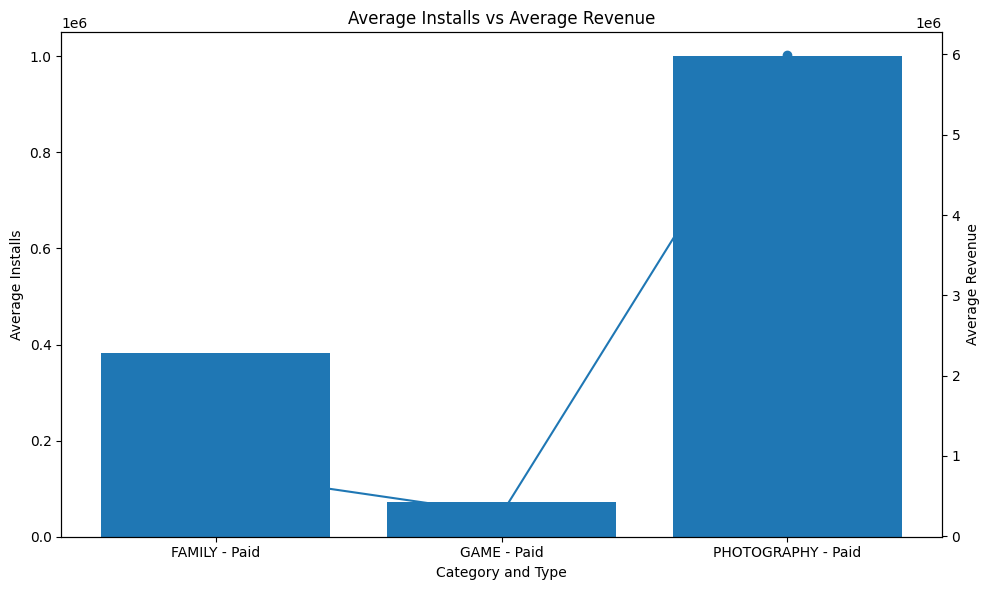

In [ ]:

# Google Play Store Data Analysis

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("E:/DATASETS/Play Store Data (1).csv")


# 1. Clean Installs Column

# Remove + and ,
df["Installs"] = df["Installs"].str.replace("+", "", regex=False)
df["Installs"] = df["Installs"].str.replace(",", "", regex=False)

# Convert to numeric
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

# Keep installs >= 10000
df = df[df["Installs"] >= 10000]


# 2. Clean Price Column

# Remove $
df["Price"] = df["Price"].str.replace("$", "", regex=False)

# Convert to numeric
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Create Revenue column
df["Revenue"] = df["Installs"] * df["Price"]

# Keep revenue >= 10000
df = df[df["Revenue"] >= 10000]


# 3. Clean Android Version

# Convert Android version into float
df["Android Ver"] = df["Android Ver"].astype(str)

def get_version(version):
    try:
        return float(version.split()[0])
    except:
        return np.nan

df["Android_Num"] = df["Android Ver"].apply(get_version)

# Keep Android version > 4.0
df = df[df["Android_Num"] > 4.0]


# 4. Clean Size Column

df["Size"] = df["Size"].astype(str)

def convert_size(size):

    if "M" in size:
        return float(size.replace("M", ""))

    elif "k" in size:
        return float(size.replace("k", "")) / 1024

    else:
        return np.nan

df["Size_MB"] = df["Size"].apply(convert_size)

# Keep size > 15 MB
df = df[df["Size_MB"] > 15]


# 5. Apply Remaining Filters

# Content Rating = Everyone
df = df[df["Content Rating"] == "Everyone"]

# App name length <= 30
df = df[df["App"].str.len() <= 30]


# 6. Find Top 3 Categories

top_categories = df["Category"].value_counts().head(3).index

df_top = df[df["Category"].isin(top_categories)]


# 7. Group Data

summary = df_top.groupby(["Category", "Type"])[["Installs", "Revenue"]].mean().reset_index()

# Rename columns
summary.rename(columns={
    "Installs": "Average_Installs",
    "Revenue": "Average_Revenue"
}, inplace=True)

# Print summary table
print(summary)


# 8. Create Dual Axis Chart

x = summary["Category"] + " - " + summary["Type"]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for installs
ax1.bar(x, summary["Average_Installs"])

ax1.set_xlabel("Category and Type")
ax1.set_ylabel("Average Installs")

# Second axis for revenue
ax2 = ax1.twinx()

# Line chart for revenue
ax2.plot(x, summary["Average_Revenue"], marker='o')

ax2.set_ylabel("Average Revenue")

# Title
plt.title("Average Installs vs Average Revenue")

# Rotate labels
plt.xticks(rotation=45)

# Adjust layout
plt.tight_layout()

# Show chart
plt.show()